In [1]:
import os
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/MyDrive')

Mounted at /content/MyDrive


In [4]:
model_name = 'unsloth/Llama-3.2-3B-Instruct'
num_classes = 3
max_seq_length = 256

In [5]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
train_path = "/content/twitter_training_3class.csv"
valid_path = "/content/twitter_valid_3class.csv"
test_path = "/content/twitter_testing_3class.csv"

In [7]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"
tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [8]:
def format_with_system_prompt(row):
    user_text = row['tweet']
    target_entity = row['entity']

    full_text = (
        f"Classify sentiment towards the target entity. "
        f"If sentiment is not directed at the target, label as other.\n\n"
        f"Text: {user_text}\n"
        f"Target: {target_entity}\n"
        f"Sentiment (other/negative/positive):"
    )

    return {"formatted_text": full_text}

In [9]:

raw_datasets = load_dataset(
    "csv",
    data_files={
        "train": train_path,
        "validation": valid_path,
        "test": test_path
    }
)

print(raw_datasets)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 9032
    })
    validation: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 1129
    })
    test: Dataset({
        features: ['tweet_id', 'entity', 'sentiment', 'tweet'],
        num_rows: 1130
    })
})


In [10]:
raw_datasets = raw_datasets.map(
    lambda x: {"sentiment": int(x["sentiment"])}
)

Map:   0%|          | 0/9032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

In [11]:
formatted_datasets = raw_datasets.map(format_with_system_prompt)

Map:   0%|          | 0/9032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

In [12]:
LABEL_WORDS = {0: "other", 1: "negative", 2: "positive"}

In [13]:
def tokenize_function(examples):
    input_ids_list, labels_list, attention_mask_list = [], [], []

    for text, sentiment in zip(examples["formatted_text"], examples["sentiment"]):
        label_word = LABEL_WORDS[sentiment]

        # tokenize label
        label_ids = tokenizer(label_word, add_special_tokens=False)["input_ids"]

        # tokenize prompt
        prefix_ids = tokenizer(
            text,
            truncation=True,
            max_length=max_seq_length - len(label_ids),
            add_special_tokens=True
        )["input_ids"]

        full_ids = prefix_ids + label_ids

        # mask everything except label
        labels = [-100] * len(prefix_ids) + label_ids

        input_ids_list.append(full_ids)
        labels_list.append(labels)
        attention_mask_list.append([1] * len(full_ids))

    return {
        "input_ids": input_ids_list,
        "attention_mask": attention_mask_list,
        "labels": labels_list,
    }

In [14]:
tokenized_datasets = formatted_datasets.map(tokenize_function, batched=True)

Map:   0%|          | 0/9032 [00:00<?, ? examples/s]

Map:   0%|          | 0/1129 [00:00<?, ? examples/s]

Map:   0%|          | 0/1130 [00:00<?, ? examples/s]

In [15]:
cols_to_remove = formatted_datasets["train"].column_names
tokenized_datasets = tokenized_datasets.remove_columns(cols_to_remove)
print(tokenized_datasets["train"].column_names)

['input_ids', 'attention_mask', 'labels']


In [16]:
!pip install -U bitsandbytes>=0.46.1

In [17]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [18]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0},
    dtype=torch.float16
)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

In [19]:
model.config.pad_token_id = tokenizer.pad_token_id
model = prepare_model_for_kbit_training(model)

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.2,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
model = get_peft_model(model, lora_config)
model.config.use_cache = False

In [20]:
LABEL_TOKEN_IDS = {}
for cls, word in LABEL_WORDS.items():
    ids = tokenizer(word, add_special_tokens=False)["input_ids"]
    if len(ids) != 1:
        raise ValueError(f"{word} is not a single token: {ids}")
    LABEL_TOKEN_IDS[cls] = ids[0]

def preprocess_logits_for_metrics(logits, labels):
    # Find the prediction position (one before the label token) per sample
    # labels shape: (batch_size, seq_len)
    # logits shape: (batch_size, seq_len, vocab_size)

    batch_size = labels.shape[0]
    label_token_ids = torch.tensor(
        list(LABEL_TOKEN_IDS.values()), device=logits.device
    )

    pred_positions = (labels != -100).long().argmax(dim=1) - 1

    scores = torch.stack([
        logits[i, pred_positions[i], label_token_ids]
        for i in range(batch_size)
    ])

    return scores

def compute_metrics(eval_pred):
    scores, labels = eval_pred

    preds = np.argmax(scores, axis=1)

    inv = {v: k for k, v in LABEL_TOKEN_IDS.items()}
    trues = []
    for i in range(len(labels)):
        first_real = next((t for t in labels[i] if t != -100), -1)
        trues.append(inv.get(int(first_real), 0))

    return {"accuracy": accuracy_score(trues, preds)}

In [21]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100
)

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/MyDrive/MyDrive/llama_sentiment_model_1",

    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,

    num_train_epochs=8,
    weight_decay=0.01,
    max_grad_norm=0.3,

    logging_strategy="steps",
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    prediction_loss_only=False,
    fp16=True,
    report_to="none"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [22]:
class_counts = torch.tensor([3781, 2761, 2490], dtype=torch.float32)
weights = 1.0 / class_counts
weights = weights / weights.sum() * len(class_counts)   # normalize
weights = weights.to(model.device)

In [23]:
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        # LM loss
        lm_loss = outputs.loss

        # prediction positions
        pred_positions = (labels != -100).long().argmax(dim=1)
        pred_positions = torch.clamp(pred_positions - 1, min=0)

        batch_size = labels.shape[0]
        label_token_ids = list(LABEL_TOKEN_IDS.values())

        scores = torch.stack([
            logits[i, pred_positions[i], label_token_ids]
            for i in range(batch_size)
        ])

        # true labels
        inv = {v: k for k, v in LABEL_TOKEN_IDS.items()}
        trues = []
        for i in range(len(labels)):
            first_real = next((t for t in labels[i] if t != -100), -1)
            trues.append(inv.get(int(first_real), 0))

        trues = torch.tensor(trues).to(model.device)

        # ensure dtype match
        local_weights = weights.to(logits.dtype)

        loss_fct = CrossEntropyLoss(weight=local_weights)
        cls_loss = loss_fct(scores, trues)

        # final loss
        loss = lm_loss + 0.5 * cls_loss

        return (loss, outputs) if return_outputs else loss

In [ ]:
trainer = WeightedTrainer(model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128009}.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.932423,1.008213,0.709163
2,1.659788,0.938494,0.736166


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.932423,1.008213,0.709163
2,1.659788,0.938494,0.736166
3,1.251001,1.016526,0.738822
4,0.797765,1.123142,0.735281
5,0.330334,1.804471,0.726428
6,0.274129,3.179575,0.720230


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

TrainOutput(global_step=1698, training_loss=1.4201938333724777, metrics={'train_runtime': 9998.9886, 'train_samples_per_second': 7.226, 'train_steps_per_second': 0.226, 'total_flos': 8.953431950308147e+16, 'train_loss': 1.4201938333724777, 'epoch': 6.0})

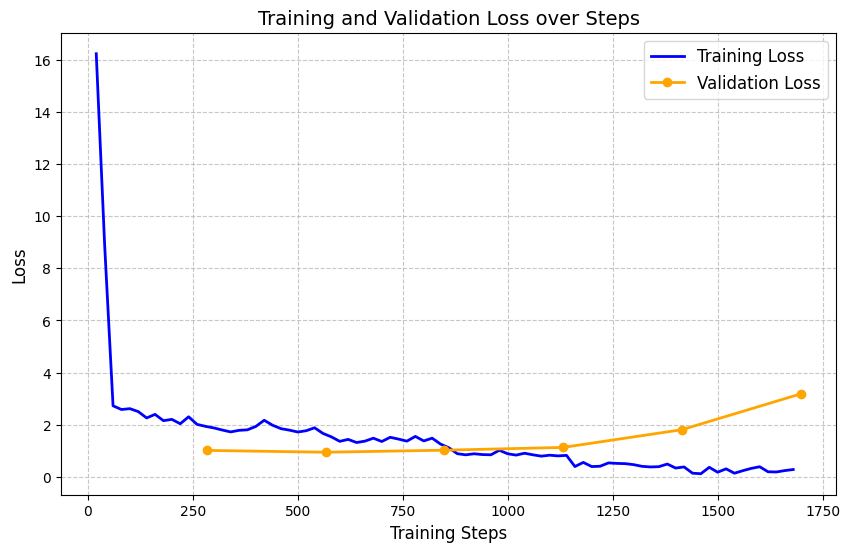

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_losses = []
eval_steps = []
eval_losses = []

for entry in log_history:
    if 'loss' in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    elif 'eval_loss' in entry:
        eval_steps.append(entry['step'])
        eval_losses.append(entry['eval_loss'])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, label='Training Loss', color='blue', linewidth=2)

if eval_steps:
    plt.plot(eval_steps, eval_losses, label='Validation Loss', color='orange', marker='o', linewidth=2)

plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss over Steps', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

In [25]:
eval_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=8,
    collate_fn=data_collator
)

In [26]:
from peft import PeftModel

model = PeftModel.from_pretrained(
    model,
    "/content/MyDrive/MyDrive/llama_sentiment_model_1/checkpoint-849"
)

In [27]:
all_predictions = []
all_true_labels = []
all_probs = []

model.eval()

label_token_ids = torch.tensor(list(LABEL_TOKEN_IDS.values()), device=model.device)
inv_label_map = {v: k for k, v in LABEL_TOKEN_IDS.items()}

with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['labels'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        batch_size = labels.shape[0]


        pred_positions = (labels != -100).long().argmax(dim=1) - 1
        pred_positions = torch.clamp(pred_positions, min=0) # Safety clamp

        scores = torch.stack([
            logits[i, pred_positions[i], label_token_ids]
            for i in range(batch_size)
        ])

        probs = torch.softmax(scores, dim=-1)
        preds = torch.argmax(scores, dim=-1)

        trues = []
        for i in range(batch_size):
            first_real = next((t for t in labels[i] if t != -100), -1)
            trues.append(inv_label_map.get(int(first_real), 0))

        all_predictions.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_true_labels.extend(trues)

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_probs = np.array(all_probs)

Evaluating:   0%|          | 0/142 [00:00<?, ?it/s]

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import numpy as np

y_true = np.array(all_true_labels)
y_pred = np.array(all_predictions)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
roc_auc = roc_auc_score(y_true, np.array(all_probs), multi_class='ovr', average='weighted')


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.7320
Precision : 0.7324
Recall    : 0.7316
F1 Score  : 0.7319
ROC-AUC   : 0.8818


In [47]:
from sklearn.metrics import classification_report

label_map = {0: "Other", 1: "Negative", 2: "Positive"}


confidences = np.max(all_probs, axis=1)

results_df = pd.DataFrame({
    'tweet_text': raw_datasets["test"]['tweet'], # Pulling directly from the HF dataset
    'true_label_num': all_true_labels,
    'predicted_label_num': all_predictions,
    'confidence': confidences
})

errors_df = results_df[results_df['true_label_num'] != results_df['predicted_label_num']]

print("="*50)
print("EVALUATION SUMMARY")
print("="*50)
# print(f"Accuracy:              {((len(results_df) - len(errors_df)) / len(results_df)) * 100:.2f}%\n")
print(f"Accuracy: 73.2%\n")


print("\n" + "="*50)
print("EXAMPLES OF INCORRECT PREDICTIONS")
print("="*50)

errors_df_sorted = errors_df.sort_values(by='confidence', ascending=False)

for index, row in errors_df_sorted.head(20).iterrows():
    actual_str = label_map.get(row['true_label_num'], "Unknown")
    pred_str = label_map.get(row['predicted_label_num'], "Unknown")

    print(f"TEXT:       {row['tweet_text']}")
    print(f"ACTUAL:     {actual_str}")
    print(f"PREDICTED:  {pred_str} (Confidence: {row['confidence']*100:.1f}%)")
    print("-" * 50)

EVALUATION SUMMARY
Accuracy: 73.2%


EXAMPLES OF INCORRECT PREDICTIONS
TEXT:       wtf we signed jota in like two hours . fifa shit
ACTUAL:     Other
PREDICTED:  Negative (Confidence: 99.5%)
--------------------------------------------------
TEXT:       wishin i could go to home depot to buy shit to build shit
ACTUAL:     Negative
PREDICTED:  Positive (Confidence: 99.3%)
--------------------------------------------------
TEXT:       nice little irl look at the details on the new cyberpunk two thousand and seventyseven xbox controller for those curious!
ACTUAL:     Positive
PREDICTED:  Other (Confidence: 99.2%)
--------------------------------------------------
TEXT:       best mseven hundred and sixtytwo suppressor best weapon forty kills duo vs squad pubg mobile via
ACTUAL:     Positive
PREDICTED:  Other (Confidence: 99.2%)
--------------------------------------------------
TEXT:       the latest warzone and modern warfare patch has leaked tons of black ops cold war details including 

In [62]:
results_df = pd.DataFrame({
    'tweet_text': raw_datasets["test"]['tweet'],
    'true_label_num': all_true_labels,
    'predicted_label_num': all_predictions,
    'probs': list(all_probs)
})

In [63]:
label_map = {0: "Other", 1: "Negative", 2: "Positive"}

pos_to_neg_errors = results_df[(results_df['true_label_num'] == 2) & (results_df['predicted_label_num'] == 1)]
neg_to_pos_errors = results_df[(results_df['true_label_num'] == 1) & (results_df['predicted_label_num'] == 2)]

def print_error_examples(df, title, num_examples=20):
    print("\n" + "="*80)
    print(f" {title}")
    print("="*80)

    if not df.empty:
        wrong_pred_idx = df.iloc[0]['predicted_label_num']
        df = df.sort_values(by="probs", key=lambda x: x.map(lambda p: p[wrong_pred_idx]), ascending=False)

    for index, row in df.head(num_examples).iterrows():
        p = row['probs']

        actual_str = label_map.get(row['true_label_num'], "Unknown")
        pred_str = label_map.get(row['predicted_label_num'], "Unknown")

        print(f"TEXT:       {row['tweet_text']}")
        print(f"ACTUAL:     {actual_str}")
        print(f"PREDICTED:  {pred_str}")
        print("SCORES:     "
              f"Other: {p[0]:>6.2%} | "
              f"Negative: {p[1]:>6.2%} | "
              f"Positive: {p[2]:>6.2%} | ")
        print("-" * 80)

print_error_examples(pos_to_neg_errors, "ACTUAL: POSITIVE -> PREDICTED: NEGATIVE", 20)
print_error_examples(neg_to_pos_errors, "ACTUAL: NEGATIVE -> PREDICTED: POSITIVE", 20)


 ACTUAL: POSITIVE -> PREDICTED: NEGATIVE
TEXT:       i really do not know why i play fortnite it is so bad
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  2.72% | Negative: 96.03% | Positive:  1.25% | 
--------------------------------------------------------------------------------
TEXT:       if they do not come out with a kobe edition i are not buying it
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  2.45% | Negative: 94.08% | Positive:  3.47% | 
--------------------------------------------------------------------------------
TEXT:       just hanging out and playing hearthstone badly .
ACTUAL:     Positive
PREDICTED:  Negative
SCORES:     Other:  5.89% | Negative: 93.67% | Positive:  0.44% | 
--------------------------------------------------------------------------------
TEXT:       there are tons and tons of quality of life improvements everywhere and it is so painful to see how the writing has taken such a massive hit and continues to disrespect both 

In [64]:
other_to_neg_errors = results_df[(results_df['true_label_num'] == 0) & (results_df['predicted_label_num'] == 1)]
other_to_pos_errors = results_df[(results_df['true_label_num'] == 0) & (results_df['predicted_label_num'] == 2)]

def print_error_examples(df, title, num_examples=20):
    print("\n" + "="*80)
    print(f" {title})")
    print("="*80)

    # Sort by the confidence of the WRONG prediction
    if not df.empty:
        wrong_pred_idx = df.iloc[0]['predicted_label_num']
        df = df.sort_values(by="probs", key=lambda x: x.map(lambda p: p[wrong_pred_idx]), ascending=False)

    for index, row in df.head(num_examples).iterrows():
        p = row['probs']

        # Map numeric labels back to strings
        actual_str = label_map.get(row['true_label_num'], "Unknown")
        pred_str = label_map.get(row['predicted_label_num'], "Unknown")

        print(f"TEXT:       {row['tweet_text']}")
        print(f"ACTUAL:     {actual_str}")
        print(f"PREDICTED:  {pred_str}")
        print("SCORES:     "
              f"Other: {p[0]:>6.2%} | "
              f"Negative: {p[1]:>6.2%} | "
              f"Positive: {p[2]:>6.2%} | ")
        print("-" * 80)

print_error_examples(other_to_neg_errors, "ACTUAL: OTHER -> PREDICTED: NEGATIVE", 20)
print_error_examples(other_to_pos_errors, "ACTUAL: OTHER -> PREDICTED: POSITIVE", 20)


 ACTUAL: OTHER -> PREDICTED: NEGATIVE)
TEXT:       wtf we signed jota in like two hours . fifa shit
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other:  0.37% | Negative: 99.54% | Positive:  0.09% | 
--------------------------------------------------------------------------------
TEXT:       microsoft just force restarted my windows pc again to install more unwanted apps. thousand and twentytenseventeentwo hundred and fifteen…. article url thousand and twentytenseventeentwo hundred and fifteen… comments url
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other:  1.10% | Negative: 98.78% | Positive:  0.12% | 
--------------------------------------------------------------------------------
TEXT:       fifa twenty our worst performance ever liverpool career mode
ACTUAL:     Other
PREDICTED:  Negative
SCORES:     Other:  2.47% | Negative: 97.27% | Positive:  0.26% | 
--------------------------------------------------------------------------------
TEXT:       holy. freaking. shit.

In [51]:
report = classification_report(all_true_labels,
    all_predictions,
    target_names=class_names,
    digits=3)

print(report)


              precision    recall  f1-score   support

       Other      0.726     0.755     0.731       473
    Negative      0.745     0.741     0.743       346
    Positive      0.704     0.704     0.704       311

    accuracy                          0.732      1130
   macro avg      0.732     0.731     0.732      1130
weighted avg      0.731     0.732     0.733      1130



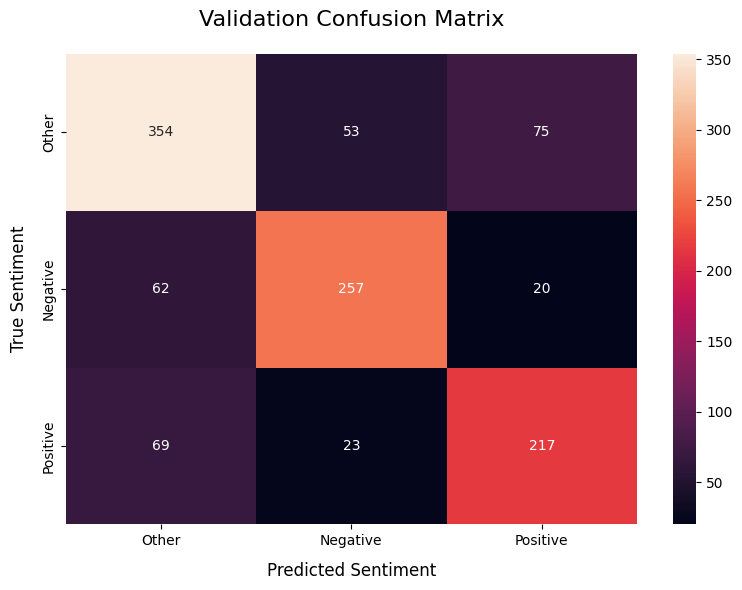

In [58]:
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True,fmt='d',   xticklabels=class_names, yticklabels=class_names)

plt.title('Validation Confusion Matrix', fontsize=16, pad=20)
plt.xlabel('Predicted Sentiment', fontsize=12, labelpad=10)
plt.ylabel('True Sentiment', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()